# Double (2-stack) Hourglass for CelebA in the Wild - 5 facial landmarks

**Notebook version:** 0.1  
**Stage:** P2 - Two-stack Hourglass with intermediate supervision  
**Master Engineering Manifest:** 0.1  
**Project Manifest:** Stage 2 / current uploaded manifest  
**Stage 2 Manifest:** 2.0  

This notebook is a surgical extension of the validated Single Hourglass baseline.

Frozen Stage 1 components are retained: data contract, constant-border preprocessing,
augmentations, heatmap generation/decoding, dataset class, DataLoaders, optimizer/scheduler
family, checkpointing, metrics, and diagnostics.

The only scientific changes are:

1. replace the single network head with a classical two-stack Hourglass architecture;
2. add intermediate supervision (`Loss = Loss(Stack 1) + Loss(Stack 2)`);
3. use feature + prediction feedback from Stack 1 before Stack 2;
4. report Stack 1 and Stack 2 validation NME separately while selecting `best.pt`
   by final Stack 2 NME.

Stage 1 reference from the supplied executed notebook:
`best validation NME = 0.030112765729427338`.


## 0. Configuration

Edit paths and runtime parameters only in this section. Later cells use the `CFG` object and do not contain operational hardcoded paths.

In [1]:
!gdown 1V5edVYcDMowNhZ4xarkP-OO_RHGQ5Y3X # val.tar.gz = 135MB
!gdown 1PFMAamN7qB4Jxl-GfLZKHK0DS4xuZSuR # train.tar.gz = 1.19GB
!mkdir -p /content/celeba_hourglass_40k
!tar -xvf /content/val.tar.gz -C /content/celeba_hourglass_40k
!tar -xvf /content/train.tar.gz -C /content/celeba_hourglass_40k

Streaming output truncated to the last 5000 lines.
train/images/173438.jpg
train/images/173444.jpg
train/images/173449.jpg
train/images/173462.jpg
train/images/173464.jpg
train/images/173465.jpg
train/images/173470.jpg
train/images/173474.jpg
train/images/173476.jpg
train/images/173477.jpg
train/images/173479.jpg
train/images/173490.jpg
train/images/173491.jpg
train/images/173493.jpg
train/images/173503.jpg
train/images/173508.jpg
train/images/173510.jpg
train/images/173515.jpg
train/images/173516.jpg
train/images/173527.jpg
train/images/173528.jpg
train/images/173535.jpg
train/images/173537.jpg
train/images/173556.jpg
train/images/173560.jpg
train/images/173566.jpg
train/images/173572.jpg
train/images/173573.jpg
train/images/173581.jpg
train/images/173596.jpg
train/images/173612.jpg
train/images/173615.jpg
train/images/173617.jpg
train/images/173622.jpg
train/images/173628.jpg
train/images/173630.jpg
train/images/173635.jpg
train/images/173637.jpg
train/images/173643.jpg
train/images/

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())
else:
    print("CUDA GPU is not available in this runtime.")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU: NVIDIA A100-SXM4-40GB
Current device: 0


In [3]:
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import Optional

@dataclass
class Config:
    # Data paths. Change these to match the current location and filenames.
    data_root: Path = Path("/content/celeba_hourglass_40k")
    train_images_dir: Path = Path("/content/celeba_hourglass_40k/train/images")
    train_annotations: Path = Path("/content/celeba_hourglass_40k/train/annotations.csv")
    val_images_dir: Path = Path("/content/celeba_hourglass_40k/val/images")
    val_annotations: Path = Path("/content/celeba_hourglass_40k/val/annotations.csv")
    output_dir: Path = Path("/content/double_hourglass_runs/run_v0_1")

    # Dependency bootstrap.
    install_missing_packages: bool = True

    # Reproducibility.
    random_seed: int = 42
    deterministic_algorithms: bool = False

    # Input and target geometry - frozen Stage 1 contract.
    image_size: int = 256
    heatmap_size: int = 64
    heatmap_sigma: float = 2.0
    num_landmarks: int = 5

    # Augmentation - frozen Stage 1 contract.
    horizontal_flip_p: float = 0.5
    affine_p: float = 0.8
    rotate_limit_deg: float = 30.0
    scale_min: float = 0.75
    scale_max: float = 1.25
    translate_limit: float = 0.10
    color_jitter_p: float = 0.5

    # Model - same Hourglass core as validated Stage 1.
    hourglass_depth: int = 4
    feature_channels: int = 256
    residual_blocks_per_level: int = 1
    num_stacks: int = 2

    # Training - kept aligned with Stage 1 for controlled comparison.
    batch_size: int = 16
    num_epochs: int = 30
    learning_rate: float = 2e-4
    weight_decay: float = 1e-5
    gradient_clip_norm: float = 1.0
    scheduler_factor: float = 0.5
    scheduler_patience: int = 3
    use_amp_on_cuda: bool = True

    # DataLoader.
    num_workers: int = 2
    prefetch_factor: int = 2

    # Audit and diagnostics.
    verify_all_image_files: bool = True
    verify_all_decoded_sizes: bool = False
    decoded_size_sample_count: int = 500
    diagnostics_samples: int = 6
    validation_visualization_samples: int = 6

    # Checkpoint resume.
    resume_from: Optional[Path] = None

    # Optional quick-development limits. Keep None for full data.
    max_train_samples: Optional[int] = None
    max_val_samples: Optional[int] = None

    # Frozen Stage 1 reference, for reporting only.
    stage1_single_best_nme: float = 0.030112765729427338

    # Version traceability.
    master_manifest_version: str = "0.1"
    project_manifest_version: str = "Stage 2"
    developer_spec_version: str = "2.0"
    notebook_version: str = "0.1"

CFG = Config()

if CFG.num_stacks != 2:
    raise ValueError("Stage P2 requires exactly two Hourglass stacks.")

# Example for local macOS:
# CFG.data_root = Path.home() / "datasets/celeba_hourglass_40k"
# CFG.train_images_dir = CFG.data_root / "train/images"
# CFG.train_annotations = CFG.data_root / "train/annotations.csv"
# CFG.val_images_dir = CFG.data_root / "val/images"
# CFG.val_annotations = CFG.data_root / "val/annotations.csv"
# CFG.output_dir = Path.cwd() / "double_hourglass_runs/run_v0_1"

print(CFG)


Config(data_root=PosixPath('/content/celeba_hourglass_40k'), train_images_dir=PosixPath('/content/celeba_hourglass_40k/train/images'), train_annotations=PosixPath('/content/celeba_hourglass_40k/train/annotations.csv'), val_images_dir=PosixPath('/content/celeba_hourglass_40k/val/images'), val_annotations=PosixPath('/content/celeba_hourglass_40k/val/annotations.csv'), output_dir=PosixPath('/content/double_hourglass_runs/run_v0_1'), install_missing_packages=True, random_seed=42, deterministic_algorithms=False, image_size=256, heatmap_size=64, heatmap_sigma=2.0, num_landmarks=5, horizontal_flip_p=0.5, affine_p=0.8, rotate_limit_deg=30.0, scale_min=0.75, scale_max=1.25, translate_limit=0.1, color_jitter_p=0.5, hourglass_depth=4, feature_channels=256, residual_blocks_per_level=1, num_stacks=2, batch_size=16, num_epochs=30, learning_rate=0.0002, weight_decay=1e-05, gradient_clip_norm=1.0, scheduler_factor=0.5, scheduler_patience=3, use_amp_on_cuda=True, num_workers=2, prefetch_factor=2, verif

## 1. Environment and dependencies

The cell installs only missing runtime packages when explicitly enabled. It then records package versions and selects CUDA, MPS, or CPU.

In [4]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "albumentations": "albumentations>=1.4,<3",
    "cv2": "opencv-python-headless>=4.8",
    "pandas": "pandas>=1.5",
    "matplotlib": "matplotlib>=3.6",
    "tqdm": "tqdm>=4.64",
}

missing = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(module_name) is None]

if missing:
    if not CFG.install_missing_packages:
        raise ImportError(
            "Missing packages: " + ", ".join(missing) +
            ". Set CFG.install_missing_packages=True or install them manually."
        )
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Dependency check complete.")

Dependency check complete.


In [5]:
import json
import math
import os
import platform
import random
import time
from contextlib import nullcontext
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Sequence, Tuple

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

def select_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = select_device()
print("Device:", DEVICE)
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Albumentations:", A.__version__)
print("OpenCV:", cv2.__version__)

Device: cuda
Python: 3.12.13
PyTorch: 2.11.0+cu128
Albumentations: 2.0.8
OpenCV: 4.13.0


In [6]:
from typing import Dict, Any

def replay_contains_applied_transform(replay_dict: Dict[str, Any], transform_name: str) -> bool:
    """Checks if a transform by name was applied in an Albumentations replay."""
    # Iterate over the list of individual transforms, each of which has an 'applied' key.
    for transform_info in replay_dict.get("transforms", []):
        # Check if the transform was applied and if its class name matches.
        if transform_info.get("applied", False) and transform_info["__class_fullname__"].endswith(transform_name):
            return True
    return False

In [7]:
def set_global_seed(seed: int, deterministic: bool = False) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.use_deterministic_algorithms(True, warn_only=True)
        if torch.cuda.is_available():
            torch.backends.cudnn.benchmark = False
            torch.backends.cudnn.deterministic = True
    elif torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True

set_global_seed(CFG.random_seed, CFG.deterministic_algorithms)

CFG.output_dir.mkdir(parents=True, exist_ok=True)
(CFG.output_dir / "figures").mkdir(exist_ok=True)

def json_ready(value: Any) -> Any:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {k: json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    return value

config_dict = json_ready(asdict(CFG))
with (CFG.output_dir / "config.json").open("w", encoding="utf-8") as f:
    json.dump(config_dict, f, indent=2, ensure_ascii=False)

environment = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "torch": torch.__version__,
    "albumentations": A.__version__,
    "opencv": cv2.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "device": str(DEVICE),
}
with (CFG.output_dir / "environment.json").open("w", encoding="utf-8") as f:
    json.dump(environment, f, indent=2, ensure_ascii=False)

print("Output directory:", CFG.output_dir.resolve())

Output directory: /content/double_hourglass_runs/run_v0_1


## 2. Input schema and dataset audit

This section validates configured paths, CSV schemas, uniqueness, finite values, coordinate bounds, split integrity, and image availability. It fails before training if a material contract is violated.

In [8]:
LANDMARK_NAMES = ("lefteye", "righteye", "nose", "leftmouth", "rightmouth")
LANDMARK_COLUMNS = [
    "lefteye_x", "lefteye_y",
    "righteye_x", "righteye_y",
    "nose_x", "nose_y",
    "leftmouth_x", "leftmouth_y",
    "rightmouth_x", "rightmouth_y",
]
REQUIRED_COLUMNS = [
    "image_id", "identity_id", *LANDMARK_COLUMNS, "crop_width", "crop_height"
]
FLIP_INDEX = np.array([1, 0, 2, 4, 3], dtype=np.int64)

def validate_paths() -> None:
    required = {
        "train_images_dir": CFG.train_images_dir,
        "train_annotations": CFG.train_annotations,
        "val_images_dir": CFG.val_images_dir,
        "val_annotations": CFG.val_annotations,
    }
    print("Resolved input paths:")
    for name, path in required.items():
        print(f"  {name}: {path.resolve()}")
        if not path.exists():
            raise FileNotFoundError(f"{name} does not exist: {path}")
    if not CFG.train_images_dir.is_dir() or not CFG.val_images_dir.is_dir():
        raise NotADirectoryError("Configured image paths must be directories.")

validate_paths()

Resolved input paths:
  train_images_dir: /content/celeba_hourglass_40k/train/images
  train_annotations: /content/celeba_hourglass_40k/train/annotations.csv
  val_images_dir: /content/celeba_hourglass_40k/val/images
  val_annotations: /content/celeba_hourglass_40k/val/annotations.csv


In [9]:
def read_and_validate_annotations(
    csv_path: Path,
    images_dir: Path,
    split_name: str,
    verify_all_files: bool,
    verify_decoded_sizes: bool,
    decoded_size_sample_count: int,
) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
    if missing_columns:
        raise ValueError(f"{split_name}: missing columns: {missing_columns}")

    df = df[REQUIRED_COLUMNS].copy()

    if df.empty:
        raise ValueError(f"{split_name}: annotation table is empty.")
    if df["image_id"].isna().any():
        raise ValueError(f"{split_name}: image_id contains NaN.")
    if df["image_id"].duplicated().any():
        examples = df.loc[df["image_id"].duplicated(), "image_id"].head().tolist()
        raise ValueError(f"{split_name}: duplicate image_id values, examples: {examples}")

    numeric_columns = [c for c in REQUIRED_COLUMNS if c != "image_id"]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="raise")

    numeric_values = df[numeric_columns].to_numpy(dtype=np.float64)
    if not np.isfinite(numeric_values).all():
        raise ValueError(f"{split_name}: non-finite numeric values detected.")

    if (df[["crop_width", "crop_height"]] <= 0).any().any():
        raise ValueError(f"{split_name}: non-positive crop dimensions detected.")

    landmarks = df[LANDMARK_COLUMNS].to_numpy(dtype=np.float32).reshape(-1, 5, 2)
    widths = df["crop_width"].to_numpy(dtype=np.float32)[:, None]
    heights = df["crop_height"].to_numpy(dtype=np.float32)[:, None]

    invalid = (
        (landmarks[..., 0] < 0) |
        (landmarks[..., 1] < 0) |
        (landmarks[..., 0] >= widths) |
        (landmarks[..., 1] >= heights)
    )
    if invalid.any():
        row_ids = np.unique(np.where(invalid)[0])[:10]
        bad_images = df.iloc[row_ids]["image_id"].tolist()
        raise ValueError(
            f"{split_name}: landmarks outside declared crop bounds. "
            f"Example image_ids: {bad_images}"
        )

    if verify_all_files:
        missing_files = [
            image_id for image_id in tqdm(df["image_id"], desc=f"{split_name}: files")
            if not (images_dir / image_id).is_file()
        ]
        if missing_files:
            raise FileNotFoundError(
                f"{split_name}: {len(missing_files)} image files are missing. "
                f"Examples: {missing_files[:10]}"
            )

    sample_n = len(df) if verify_decoded_sizes else min(decoded_size_sample_count, len(df))
    if sample_n > 0:
        sample = df.sample(sample_n, random_state=CFG.random_seed)
        mismatches = []
        for row in tqdm(sample.itertuples(index=False), total=sample_n,
                        desc=f"{split_name}: decoded sizes"):
            image_path = images_dir / row.image_id
            with Image.open(image_path) as image:
                width, height = image.size
            if width != int(row.crop_width) or height != int(row.crop_height):
                mismatches.append(
                    (row.image_id, (width, height),
                     (int(row.crop_width), int(row.crop_height)))
                )
                if len(mismatches) >= 10:
                    break
        if mismatches:
            raise ValueError(
                f"{split_name}: decoded image size differs from CSV. "
                f"Examples: {mismatches}"
            )

    print(
        f"{split_name}: {len(df):,} samples, "
        f"{df['identity_id'].nunique():,} identities, "
        f"crop W [{df.crop_width.min()}, {df.crop_width.max()}], "
        f"crop H [{df.crop_height.min()}, {df.crop_height.max()}]"
    )
    return df

train_df = read_and_validate_annotations(
    CFG.train_annotations,
    CFG.train_images_dir,
    "train",
    CFG.verify_all_image_files,
    CFG.verify_all_decoded_sizes,
    CFG.decoded_size_sample_count,
)
val_df = read_and_validate_annotations(
    CFG.val_annotations,
    CFG.val_images_dir,
    "val",
    CFG.verify_all_image_files,
    CFG.verify_all_decoded_sizes,
    CFG.decoded_size_sample_count,
)

image_overlap = set(train_df.image_id) & set(val_df.image_id)
identity_overlap = set(train_df.identity_id) & set(val_df.identity_id)
if image_overlap:
    raise ValueError(f"Train/val image overlap detected: {len(image_overlap)}")
if identity_overlap:
    raise ValueError(f"Train/val identity overlap detected: {len(identity_overlap)}")

print("Train/val image overlap: 0")
print("Train/val identity overlap: 0")

train: files:   0%|          | 0/36000 [00:00<?, ?it/s]

train: decoded sizes:   0%|          | 0/500 [00:00<?, ?it/s]

train: 36,000 samples, 8,466 identities, crop W [64, 3827], crop H [80, 5299]


val: files:   0%|          | 0/4000 [00:00<?, ?it/s]

val: decoded sizes:   0%|          | 0/500 [00:00<?, ?it/s]

val: 4,000 samples, 936 identities, crop W [65, 2532], crop H [90, 3506]
Train/val image overlap: 0
Train/val identity overlap: 0


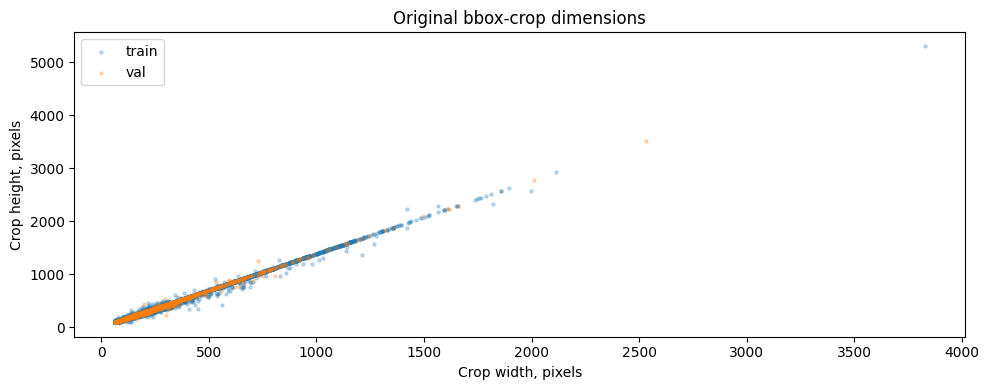

In [10]:
def plot_crop_size_distributions(train: pd.DataFrame, val: pd.DataFrame) -> None:
    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(1, 1, 1)
    ax.scatter(train["crop_width"], train["crop_height"], s=5, alpha=0.25, label="train")
    ax.scatter(val["crop_width"], val["crop_height"], s=5, alpha=0.25, label="val")
    ax.set_xlabel("Crop width, pixels")
    ax.set_ylabel("Crop height, pixels")
    ax.set_title("Original bbox-crop dimensions")
    ax.legend()
    fig.tight_layout()
    fig.savefig(CFG.output_dir / "figures/crop_dimensions.png", dpi=150)
    plt.show()

plot_crop_size_distributions(train_df, val_df)

## 3. Transforms, dataset, and heatmap targets

Geometric transforms are synchronized with keypoints. Horizontal reflection also swaps semantic left/right landmark identities. Resize preserves aspect ratio and centered reflect padding produces a 256 x 256 input.

In [11]:
def build_transform(train: bool) -> A.ReplayCompose:
    transforms: List[A.BasicTransform] = []

    if train:
        transforms.extend([
            A.HorizontalFlip(
                p=CFG.horizontal_flip_p,
            ),

            A.Affine(
                scale=(CFG.scale_min, CFG.scale_max),
                translate_percent={
                    "x": (-CFG.translate_limit, CFG.translate_limit),
                    "y": (-CFG.translate_limit, CFG.translate_limit),
                },
                rotate=(
                    -CFG.rotate_limit_deg,
                    CFG.rotate_limit_deg,
                ),
                shear=0.0,
                interpolation=cv2.INTER_LINEAR,

                # Важно: не использовать REFLECT для keypoints.
                border_mode=cv2.BORDER_CONSTANT,
                fill=0,

                p=CFG.affine_p,
            ),
        ])

    transforms.extend([
        A.LongestMaxSize(
            max_size=CFG.image_size,
            interpolation=cv2.INTER_LINEAR,
            p=1.0,
        ),

        A.PadIfNeeded(
            min_height=CFG.image_size,
            min_width=CFG.image_size,

            # Важно: также constant padding.
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,

            position="center",
            p=1.0,
        ),
    ])

    if train:
        transforms.append(
            A.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.20,
                hue=0.05,
                p=CFG.color_jitter_p,
            )
        )

    return A.ReplayCompose(
        transforms,
        keypoint_params=A.KeypointParams(
            format="xy",
            remove_invisible=False,
        ),
    )


TRAIN_TRANSFORM = build_transform(train=True)
VAL_TRANSFORM = build_transform(train=False)

Now, let's verify that `replay_contains_applied_transform` works as expected for `HorizontalFlip`.

In [12]:
# Create dummy image and keypoints for testing transforms
dummy_image = np.zeros((CFG.image_size, CFG.image_size, 3), dtype=np.uint8)
dummy_keypoints = np.array([[CFG.image_size / 2, CFG.image_size / 2]], dtype=np.float32)

# Apply TRAIN_TRANSFORM (which includes HorizontalFlip)
trained_transformed = TRAIN_TRANSFORM(image=dummy_image, keypoints=dummy_keypoints.tolist())
contains_flip_train = replay_contains_applied_transform(trained_transformed["replay"], "HorizontalFlip")
print(f"TRAIN_TRANSFORM replay contains HorizontalFlip: {contains_flip_train}")

# Apply VAL_TRANSFORM (which does not include HorizontalFlip)
val_transformed = VAL_TRANSFORM(image=dummy_image, keypoints=dummy_keypoints.tolist())
contains_flip_val = replay_contains_applied_transform(val_transformed["replay"], "HorizontalFlip")
print(f"VAL_TRANSFORM replay contains HorizontalFlip: {contains_flip_val}")

# Assertions to confirm correctness
assert contains_flip_train is True, "HorizontalFlip should be detected in TRAIN_TRANSFORM replay"
assert contains_flip_val is False, "HorizontalFlip should NOT be detected in VAL_TRANSFORM replay"

print("Verification successful: replay_contains_applied_transform works as expected.")

TRAIN_TRANSFORM replay contains HorizontalFlip: True
VAL_TRANSFORM replay contains HorizontalFlip: False
Verification successful: replay_contains_applied_transform works as expected.


In [13]:
def generate_gaussian_heatmaps(
    landmarks_xy: np.ndarray,
    visibility: np.ndarray,
    image_size: int,
    heatmap_size: int,
    sigma: float,
) -> np.ndarray:
    """Create [K, H, W] peak-one Gaussian heatmaps."""
    if landmarks_xy.shape != (CFG.num_landmarks, 2):
        raise ValueError(f"Expected landmarks shape {(CFG.num_landmarks, 2)}, got {landmarks_xy.shape}")
    if visibility.shape != (CFG.num_landmarks,):
        raise ValueError(f"Expected visibility shape {(CFG.num_landmarks,)}, got {visibility.shape}")

    heatmaps = np.zeros(
        (CFG.num_landmarks, heatmap_size, heatmap_size),
        dtype=np.float32,
    )
    scale = heatmap_size / image_size
    radius = int(math.ceil(3.0 * sigma))

    for landmark_index, ((x, y), visible) in enumerate(zip(landmarks_xy, visibility)):
        if not visible:
            continue

        center_x = float(x) * scale
        center_y = float(y) * scale

        x0 = max(0, int(math.floor(center_x - radius)))
        x1 = min(heatmap_size, int(math.ceil(center_x + radius + 1)))
        y0 = max(0, int(math.floor(center_y - radius)))
        y1 = min(heatmap_size, int(math.ceil(center_y + radius + 1)))

        if x0 >= x1 or y0 >= y1:
            continue

        xs = np.arange(x0, x1, dtype=np.float32)
        ys = np.arange(y0, y1, dtype=np.float32)[:, None]
        gaussian = np.exp(
            -((xs[None, :] - center_x) ** 2 + (ys - center_y) ** 2)
            / (2.0 * sigma ** 2)
        )
        heatmaps[landmark_index, y0:y1, x0:x1] = np.maximum(
            heatmaps[landmark_index, y0:y1, x0:x1],
            gaussian.astype(np.float32),
        )

    return heatmaps

def decode_heatmaps_argmax(
    heatmaps: torch.Tensor,
    input_size: int,
) -> torch.Tensor:
    """Decode [B, K, H, W] heatmaps to [B, K, 2] input-space coordinates."""
    if heatmaps.ndim != 4:
        raise ValueError(f"Expected [B,K,H,W], got {tuple(heatmaps.shape)}")
    batch, landmarks, height, width = heatmaps.shape
    flat_indices = heatmaps.reshape(batch, landmarks, -1).argmax(dim=-1)
    y = torch.div(flat_indices, width, rounding_mode="floor")
    x = flat_indices % width
    scale_x = input_size / width
    scale_y = input_size / height
    return torch.stack((x.float() * scale_x, y.float() * scale_y), dim=-1)

In [14]:
class CelebAFiveLandmarkDataset(Dataset):
    """CelebA bbox crops with synchronized five-landmark heatmap targets."""

    def __init__(
        self,
        annotations: pd.DataFrame,
        images_dir: Path,
        transform: A.ReplayCompose,
        max_samples: Optional[int] = None,
    ) -> None:
        self.annotations = annotations.reset_index(drop=True).copy()
        if max_samples is not None:
            self.annotations = self.annotations.iloc[:max_samples].copy()
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self) -> int:
        return len(self.annotations)

    def __getitem__(self, index: int) -> Dict[str, Any]:
        row = self.annotations.iloc[index]
        image_path = self.images_dir / str(row["image_id"])

        image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise RuntimeError(f"OpenCV could not decode: {image_path}")
        image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        original_height, original_width = image.shape[:2]

        landmarks = row[LANDMARK_COLUMNS].to_numpy(dtype=np.float32).reshape(5, 2)
        transformed = self.transform(image=image, keypoints=landmarks.tolist())
        image = transformed["image"]
        landmarks = np.asarray(transformed["keypoints"], dtype=np.float32).reshape(5, 2)

        if replay_contains_applied_transform(transformed["replay"], "HorizontalFlip"):
            landmarks = landmarks[FLIP_INDEX]

        visibility = (
            (landmarks[:, 0] >= 0.0) &
            (landmarks[:, 0] < CFG.image_size) &
            (landmarks[:, 1] >= 0.0) &
            (landmarks[:, 1] < CFG.image_size)
        ).astype(np.float32)

        heatmaps = generate_gaussian_heatmaps(
            landmarks,
            visibility,
            CFG.image_size,
            CFG.heatmap_size,
            CFG.heatmap_sigma,
        )

        image_float = image.astype(np.float32) / 255.0
        image_tensor = torch.from_numpy(image_float.transpose(2, 0, 1)).contiguous()
        image_tensor = (image_tensor - 0.5) / 0.5

        return {
            "image": image_tensor,
            "heatmaps": torch.from_numpy(heatmaps),
            "landmarks": torch.from_numpy(landmarks),
            "visibility": torch.from_numpy(visibility),
            "image_id": str(row["image_id"]),
            "identity_id": int(row["identity_id"]),
            "original_size": torch.tensor(
                [original_height, original_width], dtype=torch.long
            ),
        }

train_dataset = CelebAFiveLandmarkDataset(
    train_df, CFG.train_images_dir, TRAIN_TRANSFORM, CFG.max_train_samples
)
val_dataset = CelebAFiveLandmarkDataset(
    val_df, CFG.val_images_dir, VAL_TRANSFORM, CFG.max_val_samples
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 36000
Validation dataset: 4000


## 4. Data diagnostics

These cells visualize raw/transformed examples, verify the semantic horizontal flip, inspect heatmaps, and quantify target decoding error before model training.

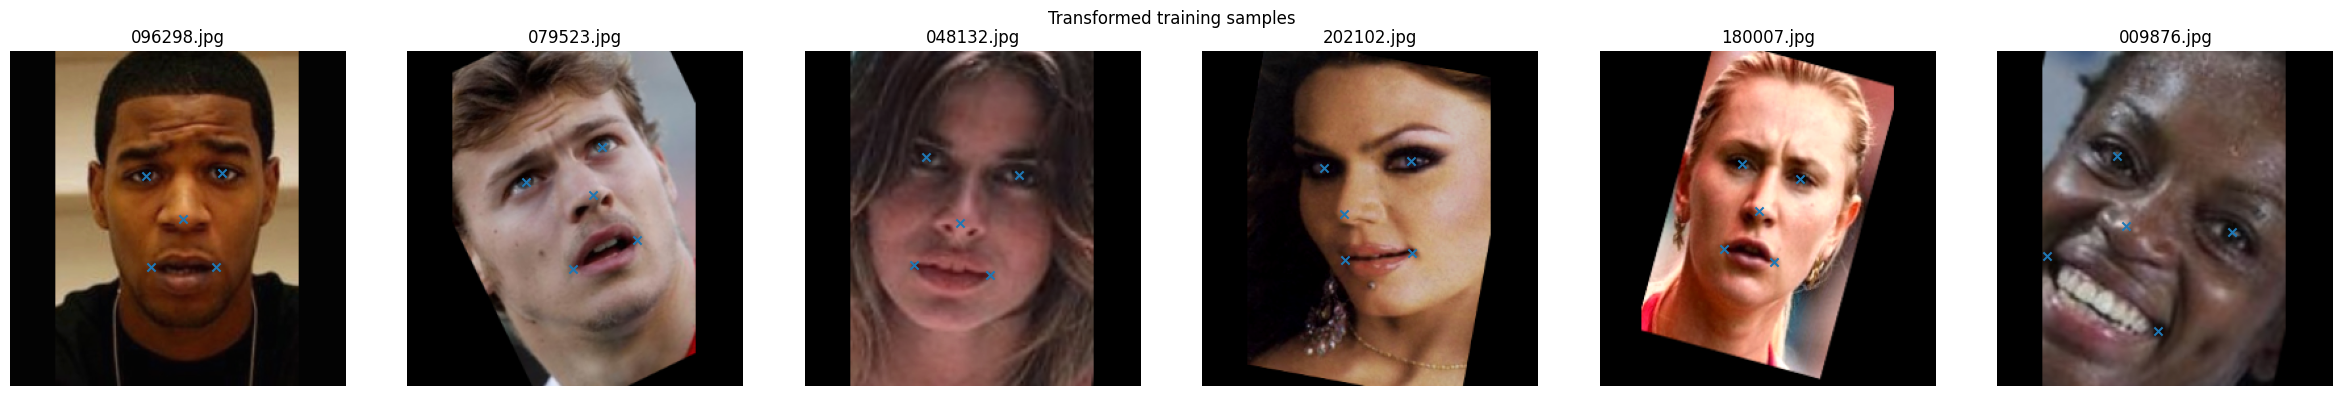

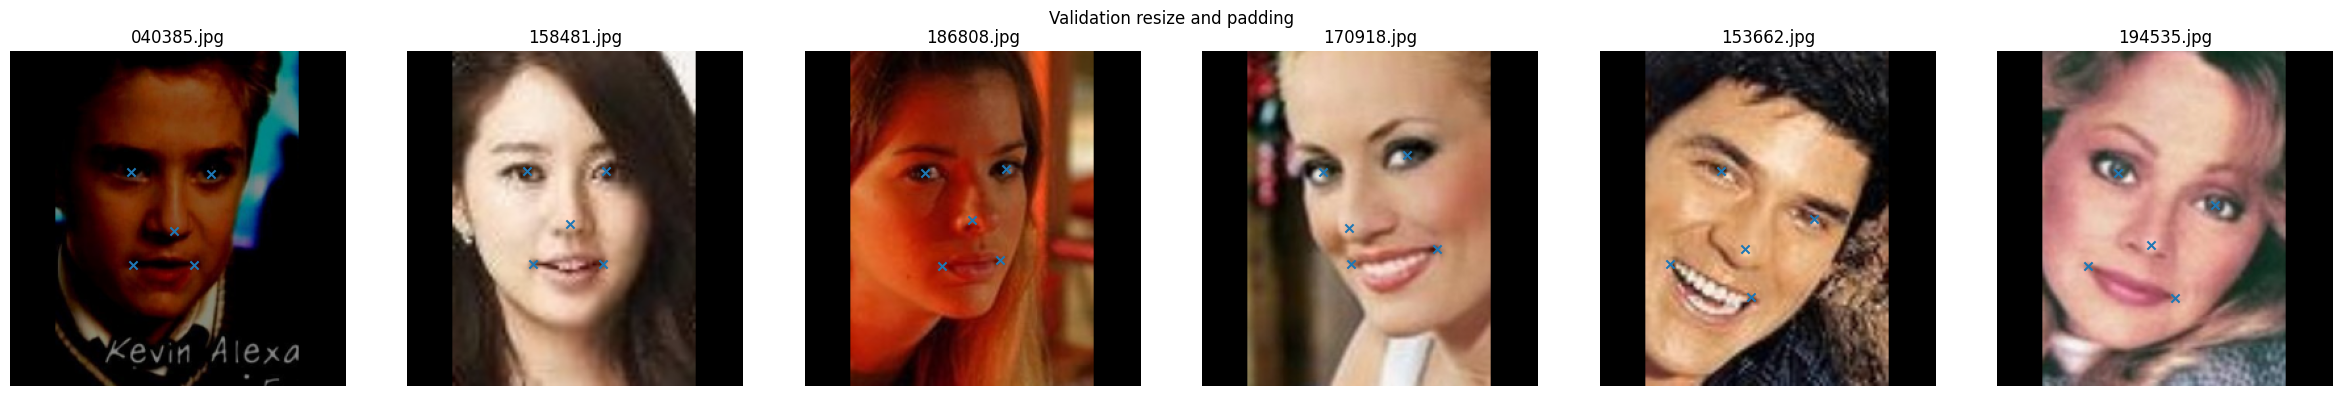

In [15]:
def denormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(image * 0.5 + 0.5, 0.0, 1.0)

def show_dataset_samples(dataset: Dataset, count: int, title: str) -> None:
    count = min(count, len(dataset))
    indices = np.linspace(0, len(dataset) - 1, count, dtype=int)
    fig, axes = plt.subplots(1, count, figsize=(4 * count, 4))
    axes = np.atleast_1d(axes)

    for axis, index in zip(axes, indices):
        sample = dataset[index]
        image = denormalize_image(sample["image"])
        landmarks = sample["landmarks"].numpy()
        visibility = sample["visibility"].numpy().astype(bool)
        axis.imshow(image)
        axis.scatter(
            landmarks[visibility, 0],
            landmarks[visibility, 1],
            s=35,
            marker="x",
            label="landmarks",
        )
        axis.set_title(sample["image_id"])
        axis.set_xlim(0, CFG.image_size)
        axis.set_ylim(CFG.image_size, 0)
        axis.axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

show_dataset_samples(train_dataset, CFG.diagnostics_samples, "Transformed training samples")
show_dataset_samples(val_dataset, CFG.diagnostics_samples, "Validation resize and padding")

In [16]:
def verify_horizontal_flip_semantics() -> None:
    image = np.zeros((120, 80, 3), dtype=np.uint8)
    landmarks = np.array([
        [20.0, 30.0],  # left eye
        [60.0, 30.0],  # right eye
        [40.0, 55.0],  # nose
        [25.0, 85.0],  # left mouth
        [55.0, 85.0],  # right mouth
    ], dtype=np.float32)

    transform = A.ReplayCompose(
        [
            A.HorizontalFlip(p=1.0),
            A.LongestMaxSize(max_size=CFG.image_size, p=1.0),
            A.PadIfNeeded(
                min_height=CFG.image_size,
                min_width=CFG.image_size,
                border_mode=cv2.BORDER_CONSTANT,
                fill=0,
                position="center",
                p=1.0,
            ),
        ],
        keypoint_params=A.KeypointParams(format="xy", remove_invisible=False),
    )
    result = transform(image=image, keypoints=landmarks.tolist())
    flipped = np.asarray(result["keypoints"], dtype=np.float32)[FLIP_INDEX]

    if not (flipped[0, 0] < flipped[1, 0] and flipped[3, 0] < flipped[4, 0]):
        raise AssertionError("Horizontal flip semantic swap failed.")

    print("Horizontal flip semantic swap: PASS")
    print("Order remains left eye, right eye, nose, left mouth, right mouth.")

verify_horizontal_flip_semantics()

Horizontal flip semantic swap: PASS
Order remains left eye, right eye, nose, left mouth, right mouth.


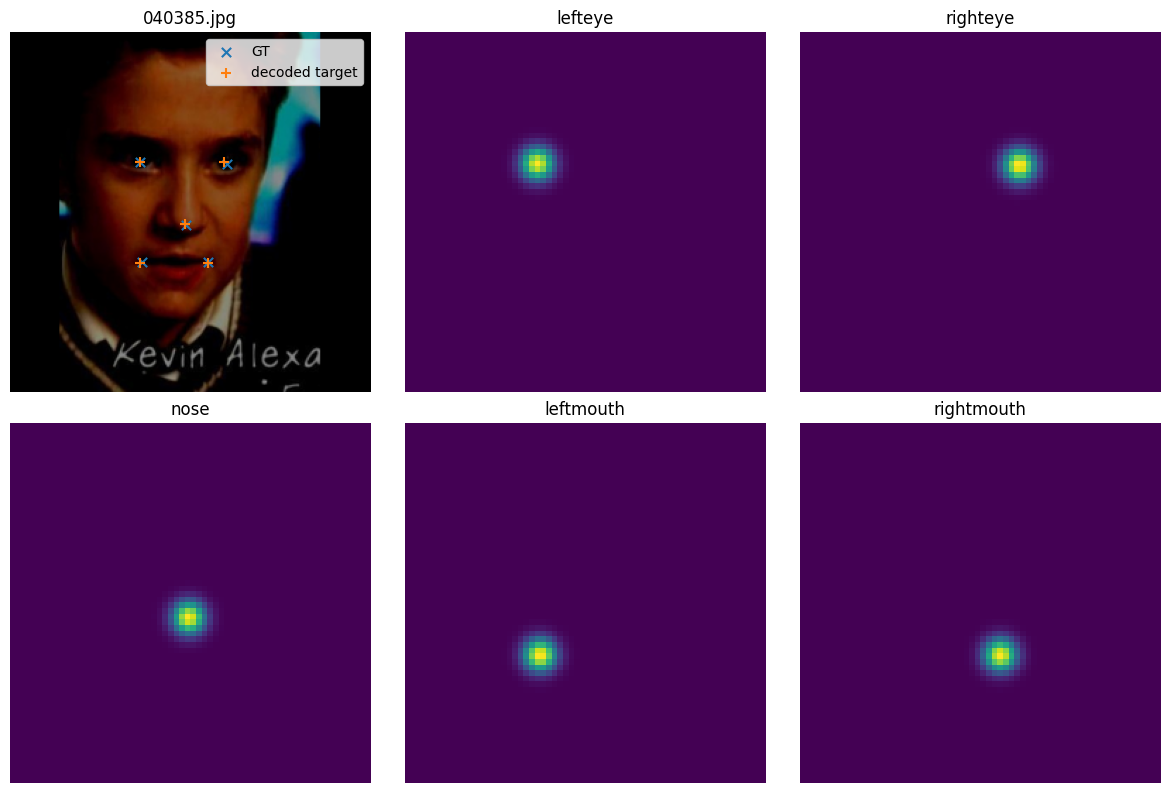

Target decode mean error, input pixels: 1.2222245931625366
Target decode max error, input pixels: 2.1026737689971924


In [17]:
def show_heatmap_diagnostic(sample: Mapping[str, Any]) -> None:
    image = denormalize_image(sample["image"])
    heatmaps = sample["heatmaps"]
    decoded = decode_heatmaps_argmax(heatmaps.unsqueeze(0), CFG.image_size)[0]
    landmarks = sample["landmarks"]
    visibility = sample["visibility"].bool()

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    axes[0].imshow(image)
    axes[0].scatter(
        landmarks[visibility, 0],
        landmarks[visibility, 1],
        marker="x",
        s=45,
        label="GT",
    )
    axes[0].scatter(
        decoded[visibility, 0],
        decoded[visibility, 1],
        marker="+",
        s=45,
        label="decoded target",
    )
    axes[0].set_title(sample["image_id"])
    axes[0].legend()
    axes[0].axis("off")

    for landmark_index, name in enumerate(LANDMARK_NAMES):
        axes[landmark_index + 1].imshow(heatmaps[landmark_index].numpy())
        axes[landmark_index + 1].set_title(name)
        axes[landmark_index + 1].axis("off")

    fig.tight_layout()
    plt.show()

    if visibility.any():
        error = torch.linalg.vector_norm(
            decoded[visibility] - landmarks[visibility], dim=-1
        )
        print("Target decode mean error, input pixels:", float(error.mean()))
        print("Target decode max error, input pixels:", float(error.max()))

show_heatmap_diagnostic(val_dataset[0])

## 5. DataLoaders

Loader settings are platform-aware. Batch shapes are checked before defining the model.

In [18]:
def make_loader(dataset: Dataset, train: bool) -> DataLoader:
    pin_memory = DEVICE.type == "cuda"
    persistent_workers = CFG.num_workers > 0
    kwargs: Dict[str, Any] = {
        "dataset": dataset,
        "batch_size": CFG.batch_size,
        "shuffle": train,
        "num_workers": CFG.num_workers,
        "pin_memory": pin_memory,
        "persistent_workers": persistent_workers,
        "drop_last": train,
    }
    if CFG.num_workers > 0:
        kwargs["prefetch_factor"] = CFG.prefetch_factor
    return DataLoader(**kwargs)

train_loader = make_loader(train_dataset, train=True)
val_loader = make_loader(val_dataset, train=False)

batch = next(iter(train_loader))
print("image:", tuple(batch["image"].shape))
print("heatmaps:", tuple(batch["heatmaps"].shape))
print("landmarks:", tuple(batch["landmarks"].shape))
print("visibility:", tuple(batch["visibility"].shape))

assert batch["image"].shape[1:] == (3, CFG.image_size, CFG.image_size)
assert batch["heatmaps"].shape[1:] == (
    CFG.num_landmarks, CFG.heatmap_size, CFG.heatmap_size
)

image: (16, 3, 256, 256)
heatmaps: (16, 5, 64, 64)
landmarks: (16, 5, 2)
visibility: (16, 5)


## 6. Model - frozen residual/Hourglass core plus two-stack feedback

`BottleneckResidual` and recursive `Hourglass` below are copied unchanged from the
validated Stage 1 notebook.

The new Stage 2 wrapper follows the classical stacked pattern:

```text
256x256 RGB
   |
 shared stem
   |                         [B,256,64,64]
   +-------------------------------+
   |                               |
 Hourglass #1                      |
   |                               |
 post #1                           |
   |                               |
   +--> head #1 --> heatmaps #1    |
   |             [B,5,64,64]       |
   |                               |
   +--> 1x1 feature projection ----+
                 +                 |
 heatmaps #1 --> 1x1 projection ---+
                 |
         fused feedback features
                 |
          Hourglass #2
                 |
             post #2
                 |
             head #2
                 |
          final heatmaps #2
```

Intermediate supervision is mandatory. Both heads are trained against the same five
Gaussian target heatmaps. During inference, Stack 2 is the default output; Stack 1 remains
available for diagnostics.


In [19]:
class BottleneckResidual(nn.Module):
    """Residual bottleneck mapping [B, Cin, H, W] to [B, Cout, H, W]."""

    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        mid_channels = out_channels // 2
        if mid_channels <= 0:
            raise ValueError("out_channels must be at least 2.")

        self.main = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                mid_channels, mid_channels, kernel_size=3, padding=1, bias=False
            ),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=1, bias=False),
        )
        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.main(x) + self.skip(x)


def make_residual_sequence(channels: int, blocks: int) -> nn.Sequential:
    if blocks < 1:
        raise ValueError("At least one residual block is required.")
    return nn.Sequential(
        *[BottleneckResidual(channels, channels) for _ in range(blocks)]
    )


class Hourglass(nn.Module):
    """Recursive Hourglass preserving [B, C, H, W] at its external boundary."""

    def __init__(self, depth: int, channels: int, blocks_per_level: int) -> None:
        super().__init__()
        if depth < 1:
            raise ValueError("Hourglass depth must be at least 1.")

        self.depth = depth
        self.up_branch = make_residual_sequence(channels, blocks_per_level)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low_pre = make_residual_sequence(channels, blocks_per_level)

        if depth > 1:
            self.low_core: nn.Module = Hourglass(
                depth - 1, channels, blocks_per_level
            )
        else:
            self.low_core = make_residual_sequence(channels, blocks_per_level)

        self.low_post = make_residual_sequence(channels, blocks_per_level)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        upper = self.up_branch(x)
        lower = self.pool(x)
        lower = self.low_pre(lower)
        lower = self.low_core(lower)
        lower = self.low_post(lower)
        lower = F.interpolate(lower, size=upper.shape[-2:], mode="nearest")
        return upper + lower

In [20]:
class DoubleHourglassNet(nn.Module):
    """Two-stack Hourglass: [B,3,256,256] -> two [B,5,64,64] heatmap tensors.

    The stem and each Hourglass/post block follow the validated Single Hourglass baseline.
    Stack 1 predictions are projected back to feature space and fused with Stack 1 features
    and the shared stem features before Stack 2.
    """

    def __init__(
        self,
        num_landmarks: int = 5,
        feature_channels: int = 256,
        hourglass_depth: int = 4,
        blocks_per_level: int = 1,
    ) -> None:
        super().__init__()

        # Frozen Stage 1 stem.
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            BottleneckResidual(64, 128),
            nn.MaxPool2d(kernel_size=2, stride=2),
            BottleneckResidual(128, 128),
            BottleneckResidual(128, feature_channels),
        )

        self.hourglass1 = Hourglass(
            hourglass_depth, feature_channels, blocks_per_level
        )
        self.post1 = nn.Sequential(
            BottleneckResidual(feature_channels, feature_channels),
            nn.Conv2d(
                feature_channels, feature_channels, kernel_size=1, bias=False
            ),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),
        )
        self.head1 = nn.Conv2d(
            feature_channels, num_landmarks, kernel_size=1, bias=True
        )

        # Classical inter-stack feedback: learned projections of both latent features
        # and intermediate heatmaps back into the common feature space.
        self.merge_features1 = nn.Conv2d(
            feature_channels, feature_channels, kernel_size=1, bias=False
        )
        self.merge_predictions1 = nn.Conv2d(
            num_landmarks, feature_channels, kernel_size=1, bias=False
        )

        self.hourglass2 = Hourglass(
            hourglass_depth, feature_channels, blocks_per_level
        )
        self.post2 = nn.Sequential(
            BottleneckResidual(feature_channels, feature_channels),
            nn.Conv2d(
                feature_channels, feature_channels, kernel_size=1, bias=False
            ),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),
        )
        self.head2 = nn.Conv2d(
            feature_channels, num_landmarks, kernel_size=1, bias=True
        )

    def _forward_stacks(
        self,
        x: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        stem_features = self.stem(x)

        stack1_features = self.hourglass1(stem_features)
        stack1_features = self.post1(stack1_features)
        heatmaps1 = self.head1(stack1_features)

        feedback = (
            stem_features
            + self.merge_features1(stack1_features)
            + self.merge_predictions1(heatmaps1)
        )

        stack2_features = self.hourglass2(feedback)
        stack2_features = self.post2(stack2_features)
        heatmaps2 = self.head2(stack2_features)

        return heatmaps1, heatmaps2, feedback

    def forward(
        self,
        x: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        heatmaps1, heatmaps2, _ = self._forward_stacks(x)
        return heatmaps1, heatmaps2

    def forward_with_feedback(
        self,
        x: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Diagnostic forward returning Stack 1, Stack 2, and fused feedback tensor."""
        return self._forward_stacks(x)


model = DoubleHourglassNet(
    num_landmarks=CFG.num_landmarks,
    feature_channels=CFG.feature_channels,
    hourglass_depth=CFG.hourglass_depth,
    blocks_per_level=CFG.residual_blocks_per_level,
).to(DEVICE)

parameter_count = sum(p.numel() for p in model.parameters())
trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {parameter_count:,}")
print(f"Trainable: {trainable_count:,}")


Parameters: 6,545,098
Trainable: 6,545,098


## 7. Two-stack loss, metrics, and smoke tests

The base masked heatmap MSE is unchanged. Stage 2 adds only the mandatory intermediate
supervision:

`total_loss = loss_stack1 + loss_stack2`.

The smoke test verifies output shapes, feedback shape, finite loss, backward propagation,
and nonzero gradients in **both** Hourglass stacks, both prediction heads, and both feedback
projections.


In [21]:
class MaskedHeatmapMSELoss(nn.Module):
    """Mean squared heatmap error over visible landmark channels."""

    def forward(
        self,
        prediction: torch.Tensor,
        target: torch.Tensor,
        visibility: torch.Tensor,
    ) -> torch.Tensor:
        if prediction.shape != target.shape:
            raise ValueError(
                f"Prediction/target shape mismatch: "
                f"{tuple(prediction.shape)} vs {tuple(target.shape)}"
            )
        if visibility.shape != prediction.shape[:2]:
            raise ValueError(
                f"Visibility shape {tuple(visibility.shape)} is incompatible "
                f"with prediction {tuple(prediction.shape)}"
            )

        mask = visibility[:, :, None, None].to(prediction.dtype)
        squared_error = (prediction - target).pow(2) * mask
        denominator = mask.sum() * prediction.shape[-2] * prediction.shape[-1]
        return squared_error.sum() / denominator.clamp_min(1.0)


class TwoStackHeatmapLoss(nn.Module):
    """Intermediate supervision: masked MSE(Stack 1) + masked MSE(Stack 2)."""

    def __init__(self) -> None:
        super().__init__()
        self.base_loss = MaskedHeatmapMSELoss()

    def forward(
        self,
        predictions: Tuple[torch.Tensor, torch.Tensor],
        target: torch.Tensor,
        visibility: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        if len(predictions) != 2:
            raise ValueError(f"Expected exactly 2 stack predictions, got {len(predictions)}.")
        loss1 = self.base_loss(predictions[0], target, visibility)
        loss2 = self.base_loss(predictions[1], target, visibility)
        return loss1 + loss2, loss1, loss2


@torch.no_grad()
def batch_nme(
    predicted_xy: torch.Tensor,
    target_xy: torch.Tensor,
    visibility: torch.Tensor,
    epsilon: float = 1e-6,
) -> Tuple[torch.Tensor, int]:
    """Return summed sample NME and valid sample count."""
    eye_distance = torch.linalg.vector_norm(
        target_xy[:, 0] - target_xy[:, 1], dim=-1
    )
    both_eyes_visible = (visibility[:, 0] > 0.5) & (visibility[:, 1] > 0.5)
    valid = both_eyes_visible & (eye_distance > epsilon)

    point_error = torch.linalg.vector_norm(predicted_xy - target_xy, dim=-1)
    visible_count = visibility.sum(dim=-1).clamp_min(1.0)
    mean_point_error = (point_error * visibility).sum(dim=-1) / visible_count
    sample_nme = mean_point_error / eye_distance.clamp_min(epsilon)

    return sample_nme[valid].sum(), int(valid.sum().item())


criterion = TwoStackHeatmapLoss()


In [22]:
def module_gradient_abs_sum(module: nn.Module) -> float:
    return sum(
        float(parameter.grad.detach().abs().sum().cpu())
        for parameter in module.parameters()
        if parameter.grad is not None
    )


def run_smoke_test(model: DoubleHourglassNet, batch: Mapping[str, Any]) -> None:
    model.train()
    images = batch["image"][:2].to(DEVICE)
    targets = batch["heatmaps"][:2].to(DEVICE)
    visibility = batch["visibility"][:2].to(DEVICE)

    model.zero_grad(set_to_none=True)
    heatmaps1, heatmaps2, feedback = model.forward_with_feedback(images)

    expected_heatmap_shape = (
        images.shape[0],
        CFG.num_landmarks,
        CFG.heatmap_size,
        CFG.heatmap_size,
    )
    expected_feedback_shape = (
        images.shape[0],
        CFG.feature_channels,
        CFG.heatmap_size,
        CFG.heatmap_size,
    )

    for stack_index, output in enumerate((heatmaps1, heatmaps2), start=1):
        if tuple(output.shape) != expected_heatmap_shape:
            raise AssertionError(
                f"Stack {stack_index} output {tuple(output.shape)} "
                f"!= expected {expected_heatmap_shape}"
            )
    if tuple(feedback.shape) != expected_feedback_shape:
        raise AssertionError(
            f"Feedback {tuple(feedback.shape)} != expected {expected_feedback_shape}"
        )

    total_loss, loss1, loss2 = criterion(
        (heatmaps1, heatmaps2), targets, visibility
    )
    for name, value in {
        "total": total_loss,
        "stack1": loss1,
        "stack2": loss2,
    }.items():
        if not torch.isfinite(value):
            raise FloatingPointError(
                f"Non-finite {name} smoke-test loss: {value.item()}"
            )

    total_loss.backward()

    gradient_checks = {
        "hourglass1": module_gradient_abs_sum(model.hourglass1),
        "head1": module_gradient_abs_sum(model.head1),
        "merge_features1": module_gradient_abs_sum(model.merge_features1),
        "merge_predictions1": module_gradient_abs_sum(model.merge_predictions1),
        "hourglass2": module_gradient_abs_sum(model.hourglass2),
        "head2": module_gradient_abs_sum(model.head2),
    }
    failed = {name: value for name, value in gradient_checks.items() if value <= 0.0}
    if failed:
        raise AssertionError(f"Missing/nonzero gradient failure: {failed}")

    model.zero_grad(set_to_none=True)

    print("Stack 1 output shape:", tuple(heatmaps1.shape))
    print("Stack 2 output shape:", tuple(heatmaps2.shape))
    print("Feedback tensor shape:", tuple(feedback.shape))
    print(
        "Smoke-test losses:",
        {
            "total": float(total_loss.detach().cpu()),
            "stack1": float(loss1.detach().cpu()),
            "stack2": float(loss2.detach().cpu()),
        },
    )
    print("Gradient absolute sums:")
    for name, value in gradient_checks.items():
        print(f"  {name}: {value:.6f}")
    print("Two-stack forward/backward smoke test: PASS")


run_smoke_test(model, batch)


Stack 1 output shape: (2, 5, 64, 64)
Stack 2 output shape: (2, 5, 64, 64)
Feedback tensor shape: (2, 256, 64, 64)
Smoke-test losses: {'total': 0.28692567348480225, 'stack1': 0.10985931009054184, 'stack2': 0.1770663559436798}
Gradient absolute sums:
  hourglass1: 2163.563635
  head1: 23.789498
  merge_features1: 81.892754
  merge_predictions1: 0.967689
  hourglass2: 991.766950
  head2: 51.406706
Two-stack forward/backward smoke test: PASS


## 8. Optimizer, scheduler, checkpoint manager, and resume

The baseline uses Adam and ReduceLROnPlateau. `latest.pt` and `best.pt` are independent artifacts.

In [23]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CFG.scheduler_factor,
    patience=CFG.scheduler_patience,
)

amp_enabled = DEVICE.type == "cuda" and CFG.use_amp_on_cuda
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

history: List[Dict[str, float]] = []
start_epoch = 0
best_nme = float("inf")
best_val_loss = float("inf")

def save_checkpoint(
    path: Path,
    epoch: int,
    best_nme_value: float,
    best_val_loss_value: float,
) -> None:
    payload = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "best_nme": best_nme_value,
        "best_val_loss": best_val_loss_value,
        "history": history,
        "config": config_dict,
        "versions": {
            "master_manifest": CFG.master_manifest_version,
            "project_manifest": CFG.project_manifest_version,
            "developer_spec": CFG.developer_spec_version,
            "notebook": CFG.notebook_version,
        },
    }
    torch.save(payload, path)

def load_checkpoint(path: Path) -> Tuple[int, float, float, List[Dict[str, float]]]:
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    if checkpoint.get("scaler_state"):
        scaler.load_state_dict(checkpoint["scaler_state"])
    return (
        int(checkpoint["epoch"]) + 1,
        float(checkpoint.get("best_nme", float("inf"))),
        float(checkpoint.get("best_val_loss", float("inf"))),
        list(checkpoint.get("history", [])),
    )

if CFG.resume_from is not None:
    if not CFG.resume_from.exists():
        raise FileNotFoundError(f"Resume checkpoint does not exist: {CFG.resume_from}")
    start_epoch, best_nme, best_val_loss, history = load_checkpoint(CFG.resume_from)
    print(f"Resumed from {CFG.resume_from} at epoch {start_epoch}")

## 9. Training and validation functions

Validation reports loss and interocular-normalized NME. Invalid NME samples are counted rather than hidden.

In [24]:
def autocast_context():
    if amp_enabled:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def train_one_epoch(
    model: DoubleHourglassNet,
    loader: DataLoader,
) -> Tuple[float, float, float]:
    model.train()
    total_loss_sum = 0.0
    stack1_loss_sum = 0.0
    stack2_loss_sum = 0.0
    sample_count = 0

    progress = tqdm(loader, desc="train", leave=False)
    for batch in progress:
        images = batch["image"].to(DEVICE, non_blocking=True)
        targets = batch["heatmaps"].to(DEVICE, non_blocking=True)
        visibility = batch["visibility"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            predictions = model(images)
            total_loss, loss1, loss2 = criterion(
                predictions, targets, visibility
            )

        if not torch.isfinite(total_loss):
            raise FloatingPointError(
                f"Non-finite training loss: {total_loss.item()}"
            )

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), CFG.gradient_clip_norm
        )
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.shape[0]
        total_loss_sum += float(total_loss.detach().cpu()) * batch_size
        stack1_loss_sum += float(loss1.detach().cpu()) * batch_size
        stack2_loss_sum += float(loss2.detach().cpu()) * batch_size
        sample_count += batch_size
        progress.set_postfix(
            total=f"{total_loss.item():.6f}",
            s1=f"{loss1.item():.6f}",
            s2=f"{loss2.item():.6f}",
        )

    denominator = max(sample_count, 1)
    return (
        total_loss_sum / denominator,
        stack1_loss_sum / denominator,
        stack2_loss_sum / denominator,
    )


@torch.no_grad()
def validate_one_epoch(
    model: DoubleHourglassNet,
    loader: DataLoader,
) -> Tuple[float, float, float, float, float, int]:
    model.eval()
    total_loss_sum = 0.0
    stack1_loss_sum = 0.0
    stack2_loss_sum = 0.0
    sample_count = 0
    nme1_sum = torch.tensor(0.0, device=DEVICE)
    nme2_sum = torch.tensor(0.0, device=DEVICE)
    valid_nme_count = 0

    progress = tqdm(loader, desc="val", leave=False)
    for batch in progress:
        images = batch["image"].to(DEVICE, non_blocking=True)
        targets = batch["heatmaps"].to(DEVICE, non_blocking=True)
        target_landmarks = batch["landmarks"].to(DEVICE, non_blocking=True)
        visibility = batch["visibility"].to(DEVICE, non_blocking=True)

        with autocast_context():
            predictions = model(images)
            total_loss, loss1, loss2 = criterion(
                predictions, targets, visibility
            )

        if not torch.isfinite(total_loss):
            raise FloatingPointError(
                f"Non-finite validation loss: {total_loss.item()}"
            )

        decoded1 = decode_heatmaps_argmax(predictions[0].float(), CFG.image_size)
        decoded2 = decode_heatmaps_argmax(predictions[1].float(), CFG.image_size)

        batch_nme1_sum, batch_valid_count1 = batch_nme(
            decoded1, target_landmarks, visibility
        )
        batch_nme2_sum, batch_valid_count2 = batch_nme(
            decoded2, target_landmarks, visibility
        )
        if batch_valid_count1 != batch_valid_count2:
            raise AssertionError(
                "Stack 1/Stack 2 valid NME sample counts unexpectedly differ."
            )

        batch_size = images.shape[0]
        total_loss_sum += float(total_loss.detach().cpu()) * batch_size
        stack1_loss_sum += float(loss1.detach().cpu()) * batch_size
        stack2_loss_sum += float(loss2.detach().cpu()) * batch_size
        sample_count += batch_size
        nme1_sum += batch_nme1_sum
        nme2_sum += batch_nme2_sum
        valid_nme_count += batch_valid_count1

    denominator = max(sample_count, 1)
    mean_nme1 = (
        float((nme1_sum / valid_nme_count).detach().cpu())
        if valid_nme_count > 0
        else float("nan")
    )
    mean_nme2 = (
        float((nme2_sum / valid_nme_count).detach().cpu())
        if valid_nme_count > 0
        else float("nan")
    )

    return (
        total_loss_sum / denominator,
        stack1_loss_sum / denominator,
        stack2_loss_sum / denominator,
        mean_nme1,
        mean_nme2,
        valid_nme_count,
    )


## 10. Full training loop

Run this cell to train. For an initial technical test, set `CFG.num_epochs` to 1-3 and optionally set sample limits in the configuration section.

In [25]:
def save_history_files(history_rows: Sequence[Mapping[str, float]]) -> None:
    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(CFG.output_dir / "history.csv", index=False)
    with (CFG.output_dir / "history.json").open("w", encoding="utf-8") as f:
        json.dump(list(history_rows), f, indent=2, ensure_ascii=False)


for epoch in range(start_epoch, CFG.num_epochs):
    epoch_start = time.perf_counter()

    (
        train_loss,
        train_stack1_loss,
        train_stack2_loss,
    ) = train_one_epoch(model, train_loader)

    (
        val_loss,
        val_stack1_loss,
        val_stack2_loss,
        val_nme_stack1,
        val_nme_stack2,
        valid_nme_count,
    ) = validate_one_epoch(model, val_loader)

    # Keep Stage 1 scheduling logic, but use the final Stack 2 NME.
    scheduler_metric = (
        val_nme_stack2 if math.isfinite(val_nme_stack2) else val_loss
    )
    scheduler.step(scheduler_metric)

    elapsed = time.perf_counter() - epoch_start
    learning_rate = optimizer.param_groups[0]["lr"]
    stack_refinement = (
        val_nme_stack1 - val_nme_stack2
        if math.isfinite(val_nme_stack1) and math.isfinite(val_nme_stack2)
        else float("nan")
    )

    row = {
        "epoch": float(epoch + 1),
        "train_loss": float(train_loss),
        "train_stack1_loss": float(train_stack1_loss),
        "train_stack2_loss": float(train_stack2_loss),
        "val_loss": float(val_loss),
        "val_stack1_loss": float(val_stack1_loss),
        "val_stack2_loss": float(val_stack2_loss),
        "val_nme_stack1": float(val_nme_stack1),
        "val_nme_stack2": float(val_nme_stack2),
        # Compatibility alias: final-stack NME is the model NME.
        "val_nme": float(val_nme_stack2),
        "stack2_nme_improvement_over_stack1": float(stack_refinement),
        "valid_nme_samples": float(valid_nme_count),
        "learning_rate": float(learning_rate),
        "elapsed_seconds": float(elapsed),
    }
    history.append(row)
    save_history_files(history)

    nme_improved = (
        math.isfinite(val_nme_stack2) and val_nme_stack2 < best_nme
    )
    loss_fallback_improved = (
        not math.isfinite(val_nme_stack2) and val_loss < best_val_loss
    )

    if nme_improved:
        best_nme = val_nme_stack2
    if val_loss < best_val_loss:
        best_val_loss = val_loss

    save_checkpoint(
        CFG.output_dir / "latest.pt",
        epoch,
        best_nme,
        best_val_loss,
    )

    if nme_improved or loss_fallback_improved:
        save_checkpoint(
            CFG.output_dir / "best.pt",
            epoch,
            best_nme,
            best_val_loss,
        )

    print(
        f"Epoch {epoch + 1:03d}/{CFG.num_epochs:03d} | "
        f"train total {train_loss:.6f} "
        f"(s1 {train_stack1_loss:.6f}, s2 {train_stack2_loss:.6f}) | "
        f"val total {val_loss:.6f} "
        f"(s1 {val_stack1_loss:.6f}, s2 {val_stack2_loss:.6f}) | "
        f"NME s1 {val_nme_stack1:.6f} -> s2 {val_nme_stack2:.6f} | "
        f"delta {stack_refinement:+.6f} | "
        f"lr {learning_rate:.2e} | {elapsed:.1f}s"
    )

print("Training complete.")


train:   0%|          | 0/2250 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001/030 | train total 0.002434 (s1 0.001206, s2 0.001229) | val total 0.000445 (s1 0.000253, s2 0.000192) | NME s1 0.039273 -> s2 0.038940 | delta +0.000332 | lr 2.00e-04 | 189.1s


train:   0%|          | 0/2250 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

...

val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 029/030 | train total 0.000190 (s1 0.000098, s2 0.000092) | val total 0.000155 (s1 0.000080, s2 0.000075) | NME s1 0.030070 -> s2 0.029877 | delta +0.000193 | lr 2.50e-05 | 160.0s


train:   0%|          | 0/2250 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 030/030 | train total 0.000178 (s1 0.000092, s2 0.000086) | val total 0.000151 (s1 0.000077, s2 0.000073) | NME s1 0.029504 -> s2 0.029256 | delta +0.000248 | lr 2.50e-05 | 159.9s
Training complete.


## 11. Learning curves

This cell reads the saved history so it also works after reopening the notebook.

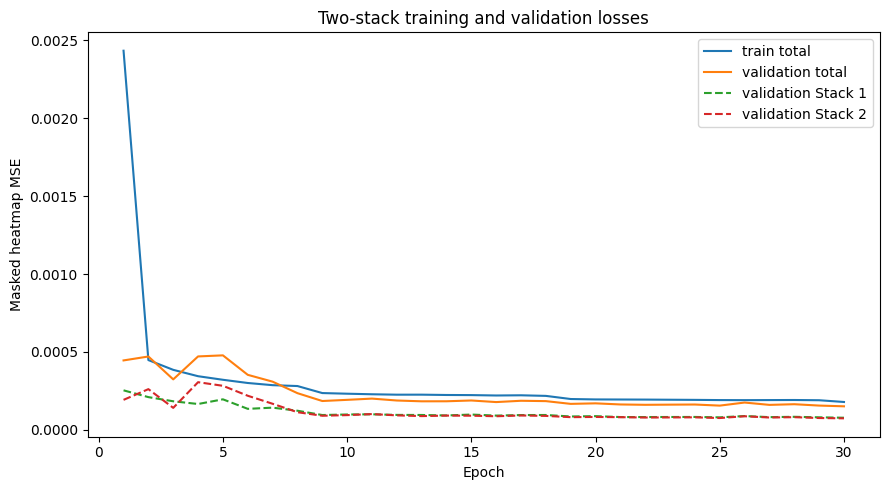

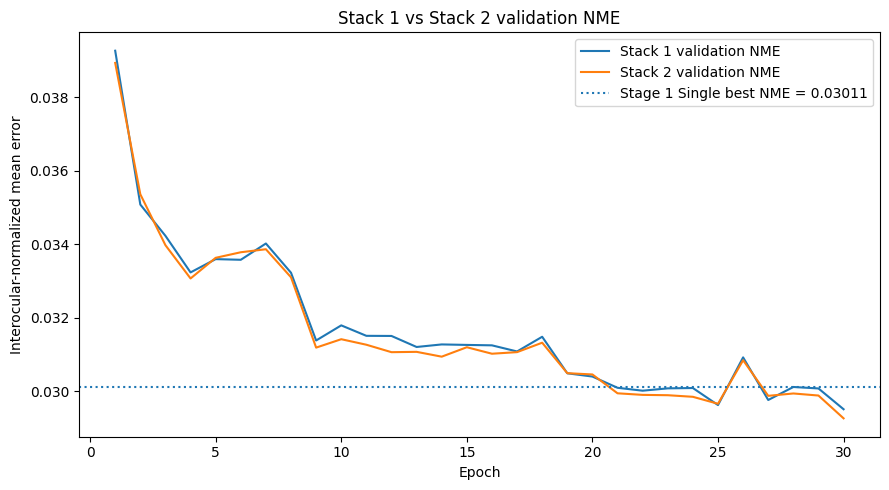

In [26]:
history_path = CFG.output_dir / "history.csv"
if not history_path.exists():
    raise FileNotFoundError(
        f"Training history not found: {history_path}. Run the training cell first."
    )

history_df = pd.read_csv(history_path)

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(history_df["epoch"], history_df["train_loss"], label="train total")
ax.plot(history_df["epoch"], history_df["val_loss"], label="validation total")
ax.plot(
    history_df["epoch"],
    history_df["val_stack1_loss"],
    linestyle="--",
    label="validation Stack 1",
)
ax.plot(
    history_df["epoch"],
    history_df["val_stack2_loss"],
    linestyle="--",
    label="validation Stack 2",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Masked heatmap MSE")
ax.set_title("Two-stack training and validation losses")
ax.legend()
fig.tight_layout()
fig.savefig(CFG.output_dir / "figures/loss_curves.png", dpi=150)
plt.show()

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(
    history_df["epoch"],
    history_df["val_nme_stack1"],
    label="Stack 1 validation NME",
)
ax.plot(
    history_df["epoch"],
    history_df["val_nme_stack2"],
    label="Stack 2 validation NME",
)
ax.axhline(
    CFG.stage1_single_best_nme,
    linestyle=":",
    label=f"Stage 1 Single best NME = {CFG.stage1_single_best_nme:.5f}",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Interocular-normalized mean error")
ax.set_title("Stack 1 vs Stack 2 validation NME")
ax.legend()
fig.tight_layout()
fig.savefig(CFG.output_dir / "figures/validation_nme.png", dpi=150)
plt.show()


## 12. Inference and qualitative validation

Load `best.pt`. Inference uses the final Stack 2 heatmaps by default, while diagnostic
figures explicitly display both Stack 1 and Stack 2 to test the refinement hypothesis.


In [27]:
best_checkpoint_path = CFG.output_dir / "best.pt"
if not best_checkpoint_path.exists():
    raise FileNotFoundError(
        f"Best checkpoint not found: {best_checkpoint_path}. Train the model first."
    )

checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("Loaded:", best_checkpoint_path)
print("Best final Stack 2 NME:", checkpoint.get("best_nme"))
print("Best total validation loss:", checkpoint.get("best_val_loss"))


Loaded: /content/double_hourglass_runs/run_v0_1/best.pt
Best final Stack 2 NME: 0.029255708679556847
Best total validation loss: 0.00015065621939720585


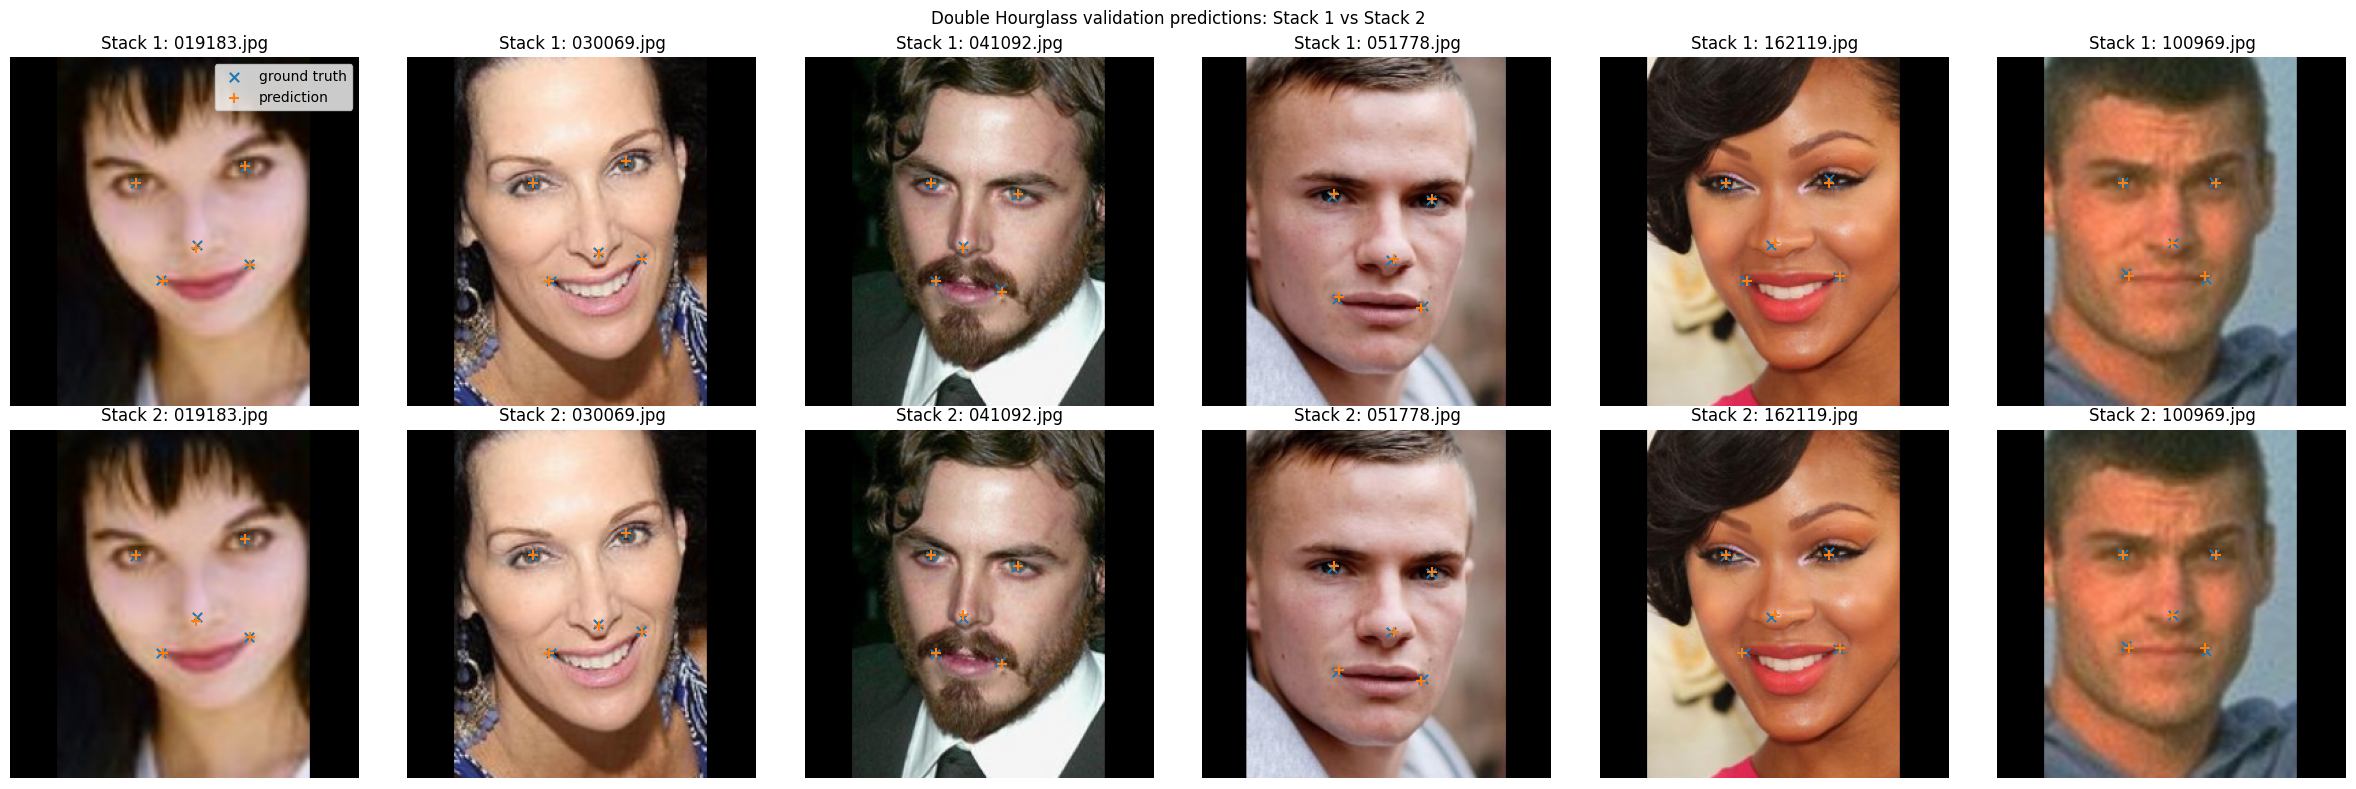

In [35]:
@torch.no_grad()
def visualize_predictions(
    model: DoubleHourglassNet,
    dataset: Dataset,
    count: int,
) -> None:
    count = min(count, len(dataset))
    rng = np.random.default_rng()
    indices = rng.choice(len(dataset), size=count, replace=False)
    fig, axes = plt.subplots(2, count, figsize=(4 * count, 8), squeeze=False)

    for column, index in enumerate(indices):
        sample = dataset[index]
        image_tensor = sample["image"].unsqueeze(0).to(DEVICE)
        prediction1, prediction2 = model(image_tensor)
        decoded1 = decode_heatmaps_argmax(
            prediction1.float(), CFG.image_size
        )[0].cpu()
        decoded2 = decode_heatmaps_argmax(
            prediction2.float(), CFG.image_size
        )[0].cpu()

        image = denormalize_image(sample["image"])
        ground_truth = sample["landmarks"]
        visibility = sample["visibility"].bool()

        for row, (decoded, stack_name) in enumerate(
            ((decoded1, "Stack 1"), (decoded2, "Stack 2"))
        ):
            axis = axes[row, column]
            axis.imshow(image)
            axis.scatter(
                ground_truth[visibility, 0],
                ground_truth[visibility, 1],
                marker="x",
                s=45,
                label="ground truth",
            )
            axis.scatter(
                decoded[visibility, 0],
                decoded[visibility, 1],
                marker="+",
                s=45,
                label="prediction",
            )
            axis.set_title(f"{stack_name}: {sample['image_id']}")
            axis.set_xlim(0, CFG.image_size)
            axis.set_ylim(CFG.image_size, 0)
            axis.axis("off")

    axes[0, 0].legend()
    fig.suptitle("Double Hourglass validation predictions: Stack 1 vs Stack 2")
    fig.tight_layout()
    fig.savefig(
        CFG.output_dir / "figures/validation_overlays_stack1_vs_stack2.png",
        dpi=150,
    )
    plt.show()


visualize_predictions(
    model, val_dataset, CFG.validation_visualization_samples
)


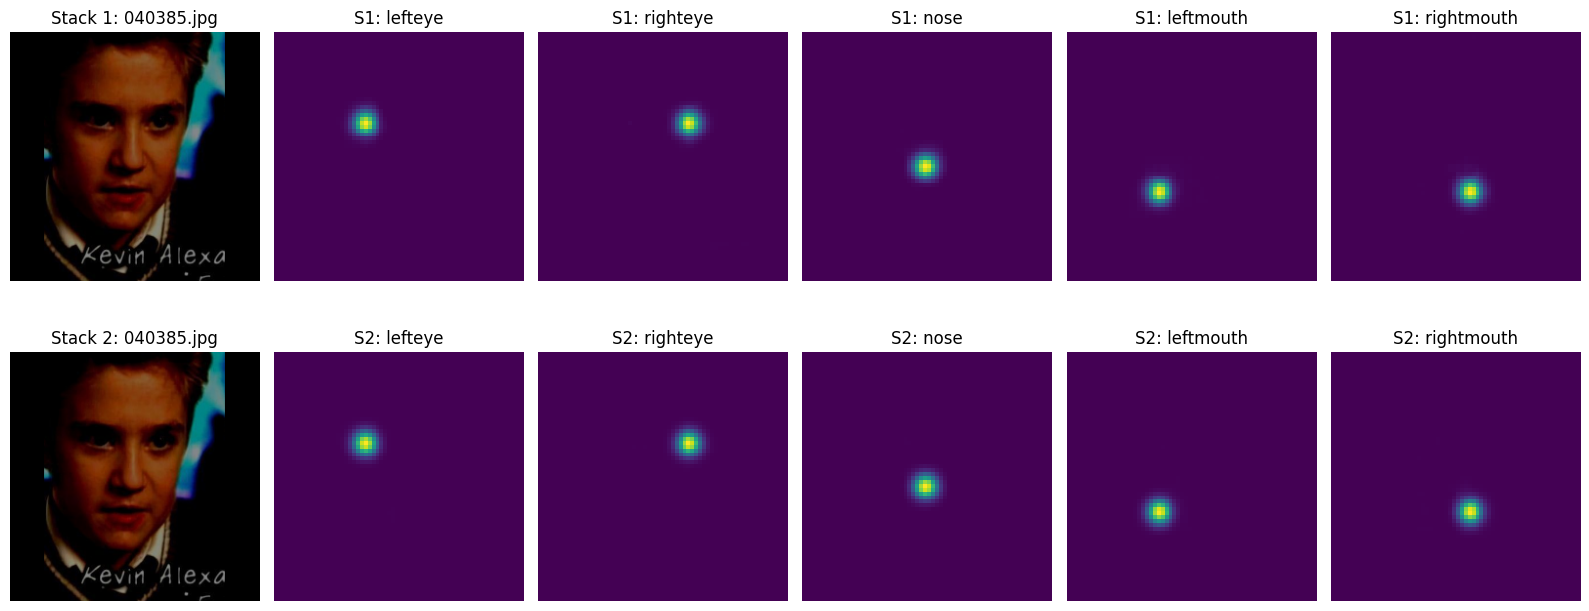

In [36]:
@torch.no_grad()
def show_predicted_heatmaps(
    model: DoubleHourglassNet,
    sample: Mapping[str, Any],
) -> None:
    prediction1, prediction2 = model(
        sample["image"].unsqueeze(0).to(DEVICE)
    )
    prediction1 = prediction1.float()[0].cpu()
    prediction2 = prediction2.float()[0].cpu()
    image = denormalize_image(sample["image"])

    fig, axes = plt.subplots(2, 6, figsize=(16, 7), squeeze=False)
    axes[0, 0].imshow(image)
    axes[0, 0].set_title(f"Stack 1: {sample['image_id']}")
    axes[1, 0].imshow(image)
    axes[1, 0].set_title(f"Stack 2: {sample['image_id']}")
    axes[0, 0].axis("off")
    axes[1, 0].axis("off")

    for index, name in enumerate(LANDMARK_NAMES):
        axes[0, index + 1].imshow(prediction1[index].numpy())
        axes[0, index + 1].set_title(f"S1: {name}")
        axes[1, index + 1].imshow(prediction2[index].numpy())
        axes[1, index + 1].set_title(f"S2: {name}")
        axes[0, index + 1].axis("off")
        axes[1, index + 1].axis("off")

    fig.tight_layout()
    fig.savefig(
        CFG.output_dir / "figures/predicted_heatmaps_stack1_vs_stack2.png",
        dpi=150,
    )
    plt.show()


show_predicted_heatmaps(model, val_dataset[0])


## 13. Optional error analysis by original crop size

This repeats the Stage 1 crop-size analysis using only the final Stack 2 output, preserving
the same grouping for later controlled comparison.


In [30]:
@torch.no_grad()
def evaluate_by_crop_size(
    model: DoubleHourglassNet,
    loader: DataLoader,
) -> pd.DataFrame:
    """Evaluate final Stack 2 NME by original crop-size group."""
    model.eval()
    rows: List[Dict[str, Any]] = []

    for batch in tqdm(loader, desc="error analysis", leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        target_landmarks = batch["landmarks"].to(DEVICE, non_blocking=True)
        visibility = batch["visibility"].to(DEVICE, non_blocking=True)
        original_size = batch["original_size"]

        _, final_predictions = model(images)
        decoded = decode_heatmaps_argmax(
            final_predictions.float(), CFG.image_size
        )

        eye_distance = torch.linalg.vector_norm(
            target_landmarks[:, 0] - target_landmarks[:, 1], dim=-1
        )
        point_error = torch.linalg.vector_norm(
            decoded - target_landmarks, dim=-1
        )
        mean_error = (
            (point_error * visibility).sum(dim=-1)
            / visibility.sum(dim=-1).clamp_min(1.0)
        )
        sample_nme = mean_error / eye_distance.clamp_min(1e-6)

        for idx in range(images.shape[0]):
            height = int(original_size[idx, 0])
            width = int(original_size[idx, 1])
            max_side = max(height, width)
            if max_side < 128:
                size_group = "small_<128"
            elif max_side < 256:
                size_group = "medium_128-255"
            else:
                size_group = "large_>=256"

            rows.append({
                "image_id": batch["image_id"][idx],
                "original_height": height,
                "original_width": width,
                "size_group": size_group,
                "nme": float(sample_nme[idx].detach().cpu()),
            })

    return pd.DataFrame(rows)


size_error_df = evaluate_by_crop_size(model, val_loader)
display(
    size_error_df.groupby("size_group")["nme"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
size_error_df.to_csv(
    CFG.output_dir / "validation_errors_by_image.csv", index=False
)


error analysis:   0%|          | 0/250 [00:00<?, ?it/s]

,count,mean,median,std
size_group,,,,
large_>=256,1633,0.026510,0.023703,0.019446
medium_128-255,1986,0.029267,0.025255,0.023486
small_<128,381,0.041309,0.029888,0.084633


## 14. Run summary and Stage 2 acceptance evidence

The summary records the final Stack 2 checkpoint and the Stage 1 reference. It does not
assume that stacking must outperform the previous model; that conclusion is empirical.

The Stage 2-specific engineering gates already checked earlier are:

- both stack outputs have shape `[B, 5, 64, 64]`;
- feedback has shape `[B, 256, 64, 64]`;
- total loss is `Loss(Stack 1) + Loss(Stack 2)`;
- both stacks and both feedback projections receive nonzero gradients;
- validation reports Stack 1 and Stack 2 NME separately.


In [31]:
best_stack2_nme = checkpoint.get("best_nme")
stage1_delta = (
    float(CFG.stage1_single_best_nme - best_stack2_nme)
    if best_stack2_nme is not None and math.isfinite(float(best_stack2_nme))
    else None
)

summary = {
    "status": "completed_notebook_execution",
    "stage": "P2_two_stack_hourglass",
    "versions": {
        "master_manifest": CFG.master_manifest_version,
        "project_manifest": CFG.project_manifest_version,
        "developer_spec": CFG.developer_spec_version,
        "notebook": CFG.notebook_version,
    },
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "parameter_count": parameter_count,
    "device": str(DEVICE),
    "best_stack2_nme": best_stack2_nme,
    "best_total_val_loss": checkpoint.get("best_val_loss"),
    "stage1_single_best_nme_reference": CFG.stage1_single_best_nme,
    "stage1_minus_stage2_nme": stage1_delta,
    "known_limitations_to_review": [
        "Argmax decoding is quantized to the 64 x 64 heatmap grid.",
        "Heatmap sigma and augmentation strength remain Stage 1 baseline choices.",
        "Small source crops may remain information-limited after upsampling.",
        "Constant border padding is retained because reflect padding duplicated keypoints in Stage 1 diagnostics.",
        "Whether Stack 2 consistently refines Stack 1 must be judged from the measured validation history and overlays.",
        "A formal Single-vs-Double controlled comparison belongs to Stage P3.",
    ],
}
with (CFG.output_dir / "run_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print("Artifacts written to:", CFG.output_dir.resolve())


{
  "status": "completed_notebook_execution",
  "stage": "P2_two_stack_hourglass",
  "versions": {
    "master_manifest": "0.1",
    "project_manifest": "Stage 2",
    "developer_spec": "2.0",
    "notebook": "0.1"
  },
  "train_samples": 36000,
  "val_samples": 4000,
  "parameter_count": 6545098,
  "device": "cuda",
  "best_stack2_nme": 0.029255708679556847,
  "best_total_val_loss": 0.00015065621939720585,
  "stage1_single_best_nme_reference": 0.030112765729427338,
  "stage1_minus_stage2_nme": 0.000857057049870491,
  "known_limitations_to_review": [
    "Argmax decoding is quantized to the 64 x 64 heatmap grid.",
    "Heatmap sigma and augmentation strength remain Stage 1 baseline choices.",
    "Small source crops may remain information-limited after upsampling.",
    "Constant border padding is retained because reflect padding duplicated keypoints in Stage 1 diagnostics.",
    "Whether Stack 2 consistently refines Stack 1 must be judged from the measured validation history and overl

## 15. Post-run review

After the complete two-stack run, record evidence rather than expectations:

- actual CUDA/MPS memory use and epoch time relative to Single Hourglass;
- training stability of total, Stack 1, and Stack 2 losses;
- whether Stack 2 NME is consistently lower than Stack 1 NME;
- whether final Stack 2 NME improves on the Stage 1 reference `0.0301127657`;
- difficult cases where Stack 2 improves or degrades Stack 1;
- whether any observed issue justifies revising a frozen upstream component.

Do **not** redesign preprocessing, heatmaps, or the Hourglass core from a single disappointing
run. Stage P3 is the controlled Single-vs-Double comparison.
